In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [2]:
# load dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# 1.EDA

## 1.1 Understand the Data

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.shape

(891, 12)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 1.2 Checking Missing Values

In [7]:
train_df.isna().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## 1.3 Target Variable Analysis

In [9]:
train_df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

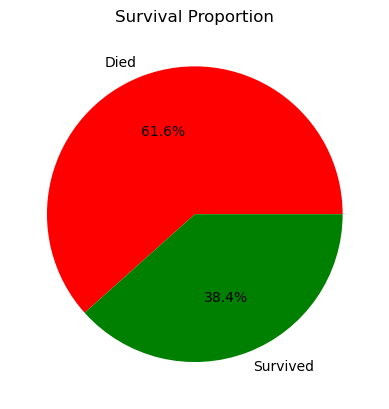

In [10]:
train_df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Died','Survived'], colors=['red','green'])
plt.title("Survival Proportion")
plt.ylabel("")
plt.show()

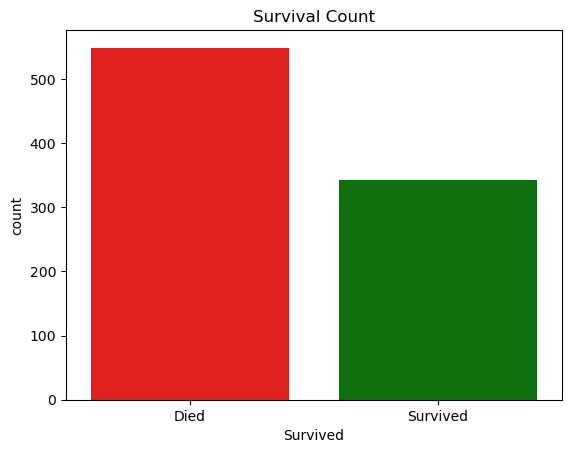

In [11]:
sns.countplot(x='Survived', data=train_df, palette=['red','green'])
plt.xticks([0, 1], ['Died', 'Survived'])
plt.title("Survival Count")
plt.show()

## 1.4 Univariate Analysis (single feature at a time)

Text(0.5, 1.0, 'Age Distribution')

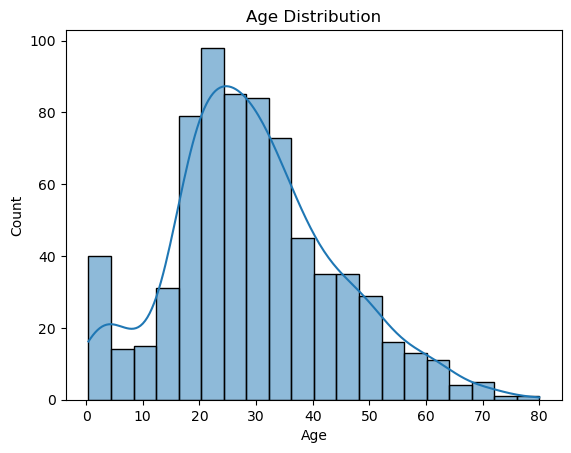

In [12]:
# Age distribution 
sns.histplot(train_df['Age'], kde=True, bins= 20)
plt.title("Age Distribution")

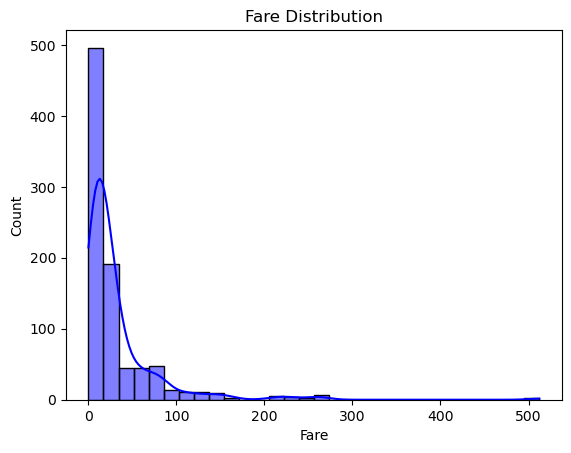

In [13]:
# Fare didtribution 
sns.histplot(train_df['Fare'], kde=True, bins=30,color='blue')
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

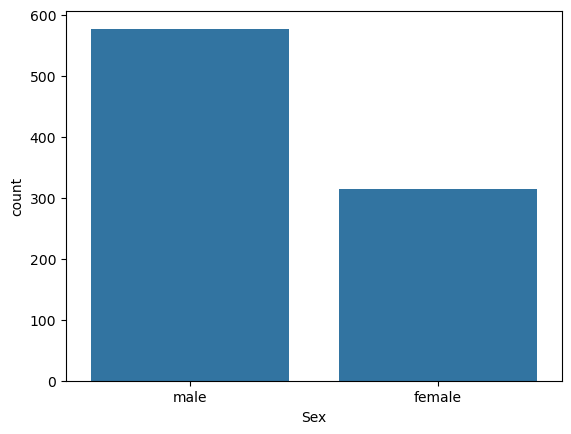

In [14]:
# Sex 
sns.countplot(x= train_df["Sex"])

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Passenger class ditribution')

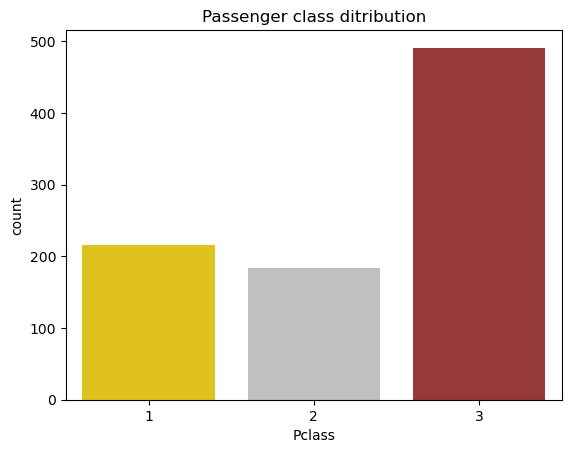

In [15]:
# passengr class ditribution 
# Percentage distribution
pclass_percent = train_df["Pclass"].value_counts(normalize=True) * 100
print(pclass_percent)
sns.countplot(x= train_df["Pclass"], palette=['gold','silver','brown'])
plt.title("Passenger class ditribution")

([<matplotlib.axis.XTick at 0x1edf53225d0>,
 [Text(0.0, 0, 'Southampton (England)'),
  Text(2.0, 0, 'Cherbourg (France)'),
  Text(1.0, 0, 'Queenstown (Ireland)')])

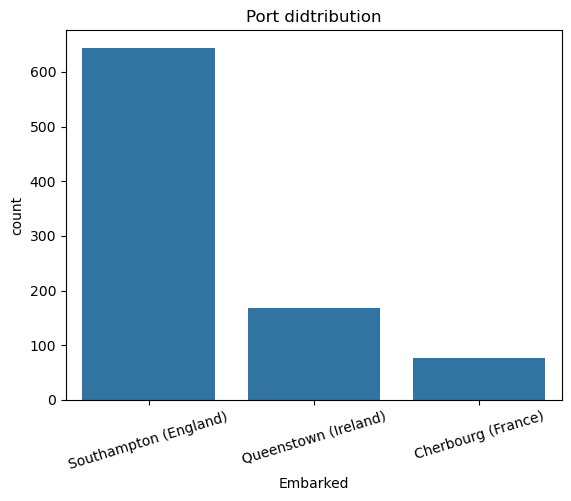

In [16]:
# Embarked --> Port distribution 
sns.countplot(x= train_df['Embarked'])
plt.title("Port didtribution")
plt.xticks(["S","Q","C"],["Southampton (England)","Cherbourg (France)","Queenstown (Ireland)"], rotation= 17)

## 1.5 Bivariate Analysis --> comparing each feature against the target

<Axes: xlabel='Sex', ylabel='count'>

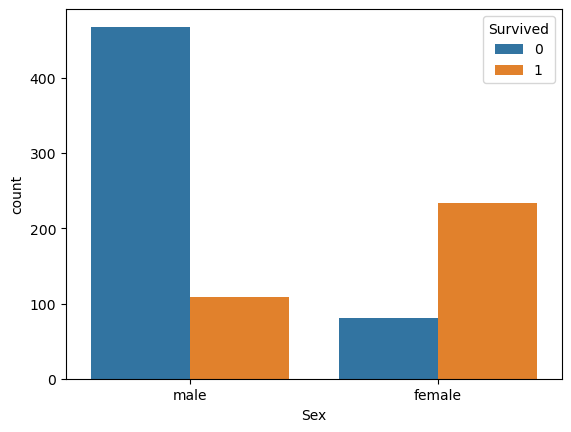

In [17]:
sns.countplot(x=train_df['Sex'], hue= train_df['Survived'])

<Axes: xlabel='Pclass', ylabel='count'>

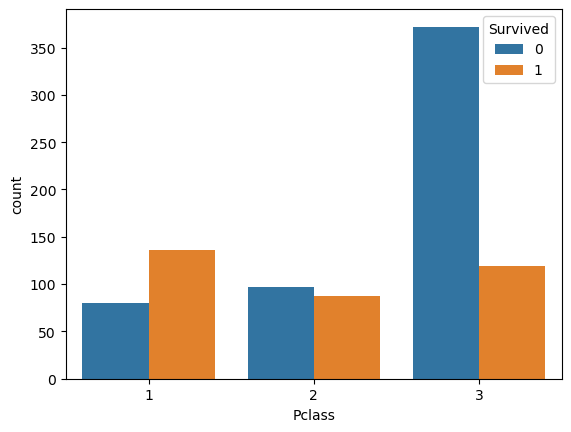

In [18]:
# passenger class vs survived 
sns.countplot(x= train_df["Pclass"], hue=train_df["Survived"])

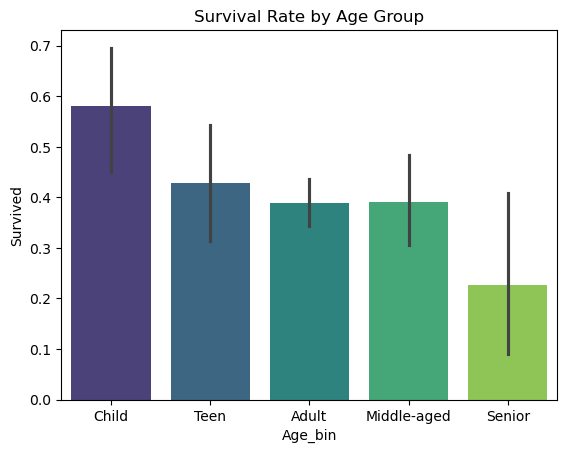

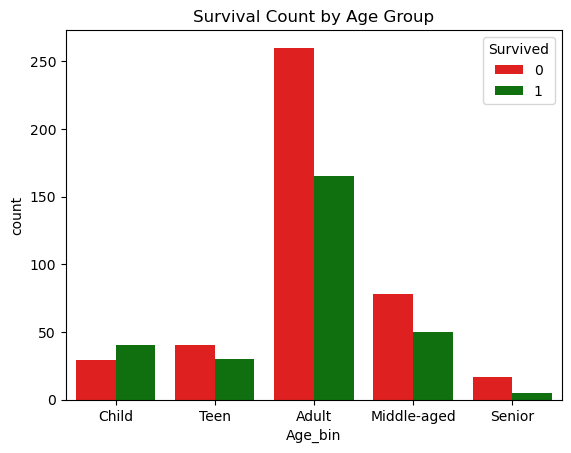

In [19]:
# Age vs Survived 
# Create Age groups
train_df['Age_bin'] = pd.cut(train_df['Age'],
                             bins=[0, 12, 18, 40, 60, 80],
                             labels=['Child','Teen','Adult','Middle-aged','Senior'])
train_df.head(1)
test_df['Age_bin'] = pd.cut(test_df['Age'],
                             bins=[0, 12, 18, 40, 60, 80],
                             labels=['Child','Teen','Adult','Middle-aged','Senior'])

sns.barplot(x='Age_bin', y='Survived', data=train_df, palette='viridis')
plt.title("Survival Rate by Age Group")
plt.show()

sns.countplot(x='Age_bin', hue='Survived', data=train_df, palette={0:'red',1:'green'})
plt.title("Survival Count by Age Group")
plt.show()

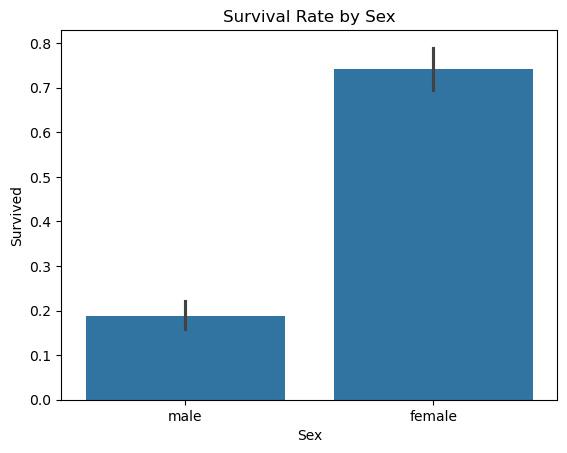

In [20]:
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title("Survival Rate by Sex")
plt.show()

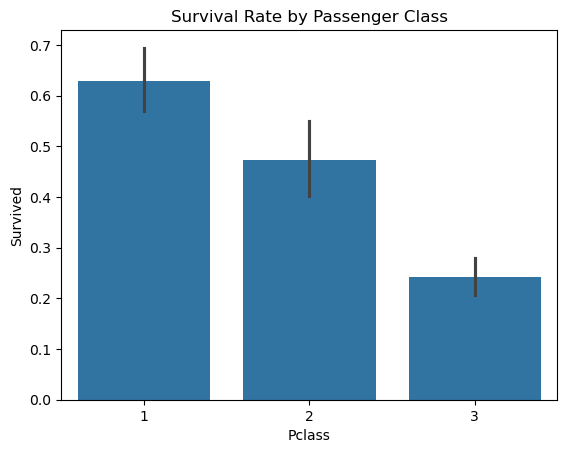

In [21]:
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title("Survival Rate by Passenger Class")
plt.show()

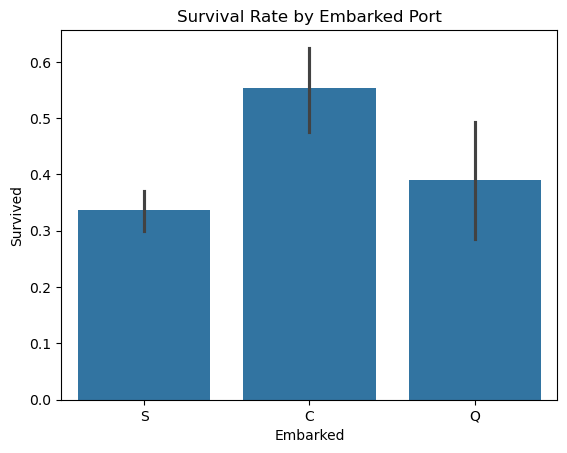

In [22]:
sns.barplot(x='Embarked', y='Survived', data=train_df)
plt.title("Survival Rate by Embarked Port")
plt.show()

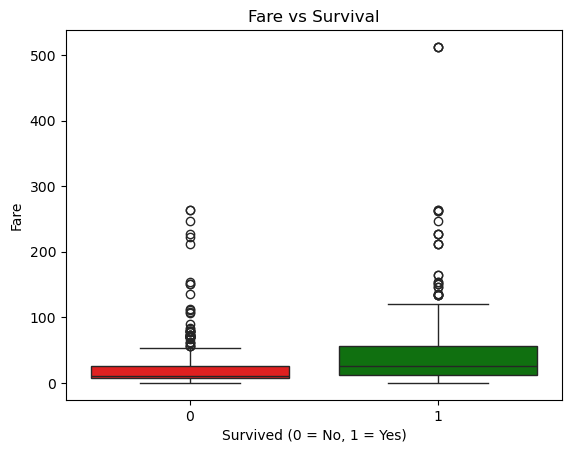

In [23]:
sns.boxplot(x='Survived', y='Fare', data=train_df, palette=['red','green'])
plt.title("Fare vs Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

# Handle Missing Values 

In [24]:
# Count missing values per column
missing = train_df.isna().sum()

# Filter only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

# Calculate percentage of missing values
missing_pct = (missing / len(train_df) * 100).round(2)

# Create summary DataFrame
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})

print(f"Features with missing values: {len(missing_df)}")
missing_df

Features with missing values: 4


,Count,Percent
Cabin,687,77.10
Age,177,19.87
Age_bin,177,19.87
Embarked,2,0.22


In [25]:
# Count missing values per column
missing = test_df.isna().sum()

# Filter only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

# Calculate percentage of missing values
missing_pct = (missing / len(test_df) * 100).round(2)

# Create summary DataFrame
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})

print(f"Features with missing values: {len(missing_df)}")
missing_df

Features with missing values: 4


,Count,Percent
Cabin,327,78.23
Age,86,20.57
Age_bin,86,20.57
Fare,1,0.24


In [26]:
# drop cabin too many missing values 
train_df.drop(columns=['Cabin'], inplace=True)
test_df.drop(columns=["Cabin"], inplace=True)
train_df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,S,Adult


In [27]:
# handle Embarked missing values 
# Fill missing Embarked with mode (most frequent value)
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
"""
train_df['Embarked'].fillna('S', inplace=True)
"""

"\ntrain_df['Embarked'].fillna('S', inplace=True)\n"

In [28]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Age_bin        177
dtype: int64

In [29]:
# droping Ticket which is not inportant 
train_df.drop(columns=["Ticket"], inplace=True)
test_df.drop(columns=["Ticket"], inplace=True)

In [30]:
train_df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Age_bin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.25,S,Adult


In [31]:
test_df.isna().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
Age_bin        86
dtype: int64

In [32]:
# dropping name having no useful information 
train_df.drop(columns=["Name"], inplace=True)
test_df.drop(columns=["Name"], inplace=True)
train_df.head(1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_bin
0,1,0,3,male,22.0,1,0,7.25,S,Adult


In [33]:
test_df.head(2)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_bin
0,892,3,male,34.5,0,0,7.8292,Q,Adult
1,893,3,female,47.0,1,0,7.0000,S,Middle-aged


In [34]:
test_df.isna().sum()

PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
Age_bin        86
dtype: int64

In [35]:
# Predictive Imputation for Age --> filling age with with prdection from model 
from sklearn.ensemble import RandomForestRegressor 

df = train_df.copy() 
# Encode categorical variables
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


In [36]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_bin,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,Adult,False,True
1,2,1,1,1,38.0,1,0,71.2833,Adult,False,False
2,3,1,3,1,26.0,0,0,7.9250,Adult,False,True
3,4,1,1,1,35.0,1,0,53.1000,Adult,False,True
4,5,0,3,0,35.0,0,0,8.0500,Adult,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,Adult,False,True
887,888,1,1,1,19.0,0,0,30.0000,Adult,False,True
888,889,0,3,1,NaN,1,2,23.4500,NaN,False,True
889,890,1,1,0,26.0,0,0,30.0000,Adult,False,False


In [37]:
# Features to predict Age
features = ['Pclass','Sex','SibSp','Parch','Fare','Embarked_Q','Embarked_S']

# Split into known and unknown Age
known_age = df[df['Age'].notnull()]
unknown_age = df[df['Age'].isnull()]

In [38]:
known_age

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_bin,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,Adult,False,True
1,2,1,1,1,38.0,1,0,71.2833,Adult,False,False
2,3,1,3,1,26.0,0,0,7.9250,Adult,False,True
3,4,1,1,1,35.0,1,0,53.1000,Adult,False,True
4,5,0,3,0,35.0,0,0,8.0500,Adult,False,True
...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,1,39.0,0,5,29.1250,Adult,True,False
886,887,0,2,0,27.0,0,0,13.0000,Adult,False,True
887,888,1,1,1,19.0,0,0,30.0000,Adult,False,True
889,890,1,1,0,26.0,0,0,30.0000,Adult,False,False


In [39]:
X_train = known_age[features]
y_train = known_age['Age']

# Train model
rfr = RandomForestRegressor(random_state=42, n_estimators=100)
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
# Predict missing Age values
predicted_ages = rfr.predict(unknown_age[features])

In [41]:
# Fill the missing Age values in the dataframe
df.loc[df['Age'].isnull(), 'Age'] = predicted_ages

In [42]:
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

In [43]:
test_df.isna().sum()

PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            0
Embarked        0
Age_bin        86
dtype: int64

In [44]:

# Select rows with missing Age
# Create dummies for Embarked in test_df
# Convert Sex to numeric
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True)
unknown_age_test = test_df[test_df['Age'].isnull()]

# Predict Age using trained rfr
predicted_ages_test = rfr.predict(unknown_age_test[features])

# Fill missing Age values
test_df.loc[test_df['Age'].isnull(), 'Age'] = predicted_ages_test

In [45]:
df['Age_bin'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 40, 60, 80],
    labels=['Child','Teen','Adult','Middle-aged','Senior']
)

In [46]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Age_bin        0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [47]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_bin,Embarked_Q,Embarked_S
0,1,0,3,0,22.00,1,0,7.2500,Adult,False,True
1,2,1,1,1,38.00,1,0,71.2833,Adult,False,False
2,3,1,3,1,26.00,0,0,7.9250,Adult,False,True
3,4,1,1,1,35.00,1,0,53.1000,Adult,False,True
4,5,0,3,0,35.00,0,0,8.0500,Adult,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.00,0,0,13.0000,Adult,False,True
887,888,1,1,1,19.00,0,0,30.0000,Adult,False,True
888,889,0,3,1,16.39,1,2,23.4500,Teen,False,True
889,890,1,1,0,26.00,0,0,30.0000,Adult,False,False


# Model Training

## Logistic Regression Model

In [48]:
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Age_bin,Embarked_Q,Embarked_S
0,892,3,0,34.5,0,0,7.8292,Adult,True,False
1,893,3,1,47.0,1,0,7.0000,Middle-aged,False,True
2,894,2,0,62.0,0,0,9.6875,Senior,True,False
3,895,3,0,27.0,0,0,8.6625,Adult,False,True
4,896,3,1,22.0,1,1,12.2875,Adult,False,True


In [49]:
test_df.isna().sum()

PassengerId     0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Age_bin        86
Embarked_Q      0
Embarked_S      0
dtype: int64

In [50]:
test_df['Age_bin'] = pd.cut(
    test_df['Age'],
    bins=[0, 12, 18, 40, 60, 80],
    labels=['Child','Teen','Adult','Middle-aged','Senior']
)

In [51]:
df.isna().sum()


PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Age_bin        0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [52]:
test_df.isna().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Age_bin        0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [53]:
df.head(5)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_bin,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,Adult,False,True
1,2,1,1,1,38.0,1,0,71.2833,Adult,False,False
2,3,1,3,1,26.0,0,0,7.9250,Adult,False,True
3,4,1,1,1,35.0,1,0,53.1000,Adult,False,True
4,5,0,3,0,35.0,0,0,8.0500,Adult,False,True


In [54]:
test_df.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Age_bin,Embarked_Q,Embarked_S
0,892,3,0,34.5,0,0,7.8292,Adult,True,False
1,893,3,1,47.0,1,0,7.0000,Middle-aged,False,True
2,894,2,0,62.0,0,0,9.6875,Senior,True,False
3,895,3,0,27.0,0,0,8.6625,Adult,False,True
4,896,3,1,22.0,1,1,12.2875,Adult,False,True


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Features
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked_Q','Embarked_S']

# Ensure dummies are numeric
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
test_df['Embarked_Q'] = test_df['Embarked_Q'].astype(int)
test_df['Embarked_S'] = test_df['Embarked_S'].astype(int)

# Train set
X = df[features]
y = df['Survived']

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train Logistic Regression
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_scaled, y_train)

# Evaluate
y_pred = logreg.predict(X_val_scaled)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

# Predict on test_df
X_test_scaled = scaler.transform(test_df[features])
predictions = logreg.predict(X_test_scaled)

# Save submission
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions
})
submission.to_csv("submission.csv", index=False)

Validation Accuracy: 0.8100558659217877


In [56]:
# Decision tree 
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Evaluate
y_pred_dt = dtree.predict(X_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_dt))

Decision Tree Accuracy: 0.8324022346368715


In [57]:
# Random forest 
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))

Random Forest Accuracy: 0.8100558659217877


Logistic Regression Accuracy: 0.8100558659217877
Decision Tree Accuracy: 0.8324022346368715
Random Forest Accuracy: 0.8100558659217877


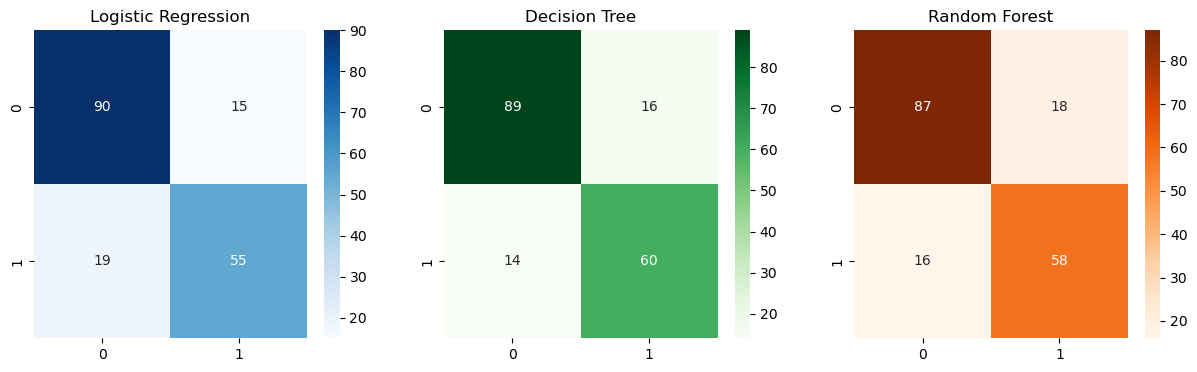

In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
y_pred_log = logreg.predict(X_val_scaled)
acc_log = accuracy_score(y_val, y_pred_log)
cm_log = confusion_matrix(y_val, y_pred_log)

# Decision Tree
y_pred_dt = dtree.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
cm_dt = confusion_matrix(y_val, y_pred_dt)

# Random Forest
y_pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
cm_rf = confusion_matrix(y_val, y_pred_rf)

print("Logistic Regression Accuracy:", acc_log)
print("Decision Tree Accuracy:", acc_dt)
print("Random Forest Accuracy:", acc_rf)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(cm_log, annot=True, fmt='d', cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(cm_dt, annot=True, fmt='d', cmap="Greens", ax=axes[1])
axes[1].set_title("Decision Tree")

sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Oranges", ax=axes[2])
axes[2].set_title("Random Forest")

plt.show()


# Decision Tree Hyperparameter Tuning

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy'
)
grid_dt.fit(X_train, y_train)

print("Best Decision Tree Params:", grid_dt.best_params_)
print("Best Decision Tree Accuracy:", grid_dt.best_score_)


Best Decision Tree Params: {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Decision Tree Accuracy: 0.8230079779375554


# Random Forest Hyperparameter Tuning

In [60]:
from sklearn.ensemble import RandomForestClassifier
# Define parameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best Random Forest Params:", grid_rf.best_params_)
print("Best Random Forest Accuracy:", grid_rf.best_score_)


Best Random Forest Params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Random Forest Accuracy: 0.8314291342460356
